In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Python\Pandas\historical_automobile_sales.csv")

In [3]:
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


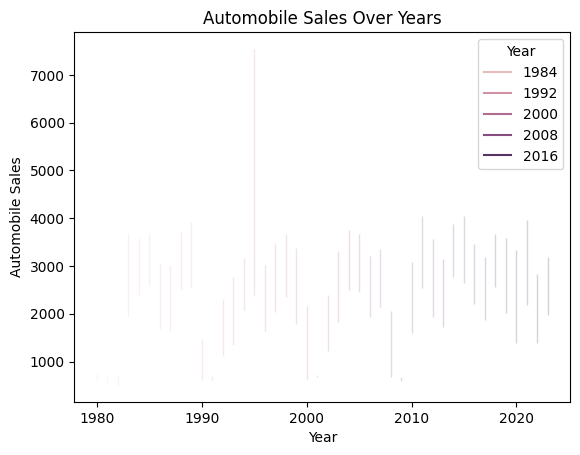

In [4]:
#Develop a Line chart using the functionality of pandas to show how. automobile sales fluctuate from year to year
sns.lineplot(data=df, x="Year", y="Automobile_Sales", hue="Year")
plt.title("Automobile Sales Over Years")
plt.xlabel("Year")
plt.ylabel("Automobile Sales")
plt.show()

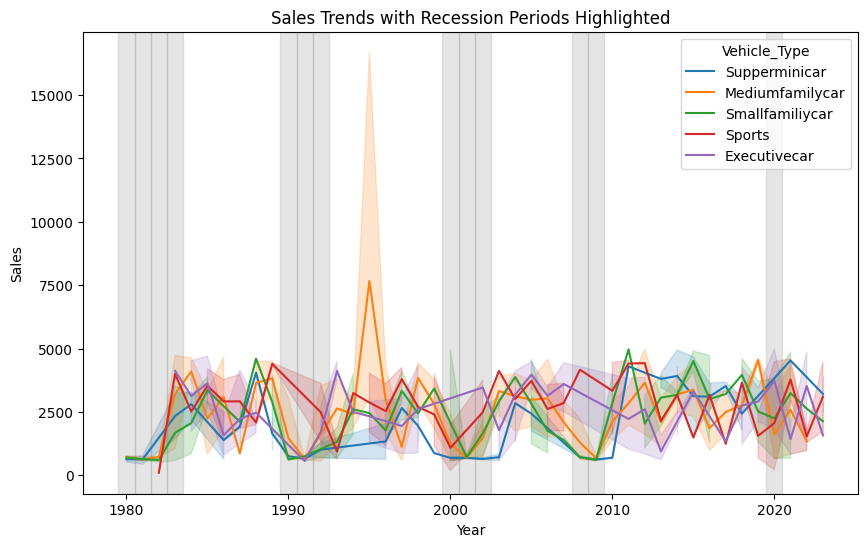

In [5]:
#Plot different lines for categories of vehicle type and analyse the trend to answer the question Is there a noticeable difference in sales trends between different vehicle types during recession periods?
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Year", y="Automobile_Sales", hue="Vehicle_Type")
for year in df[df['Recession'] == 1]['Year'].unique():
    plt.axvspan(year-0.5, year+0.5, color='gray', alpha=0.2)
plt.title("Sales Trends with Recession Periods Highlighted")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

In [6]:
df[['Recession', 'Vehicle_Type']]

,Recession,Vehicle_Type
0,1,Supperminicar
1,1,Supperminicar
2,1,Mediumfamilycar
3,1,Supperminicar
4,1,Smallfamiliycar
...,...,...
523,0,Executivecar
524,0,Smallfamiliycar
525,0,Sports
526,0,Smallfamiliycar


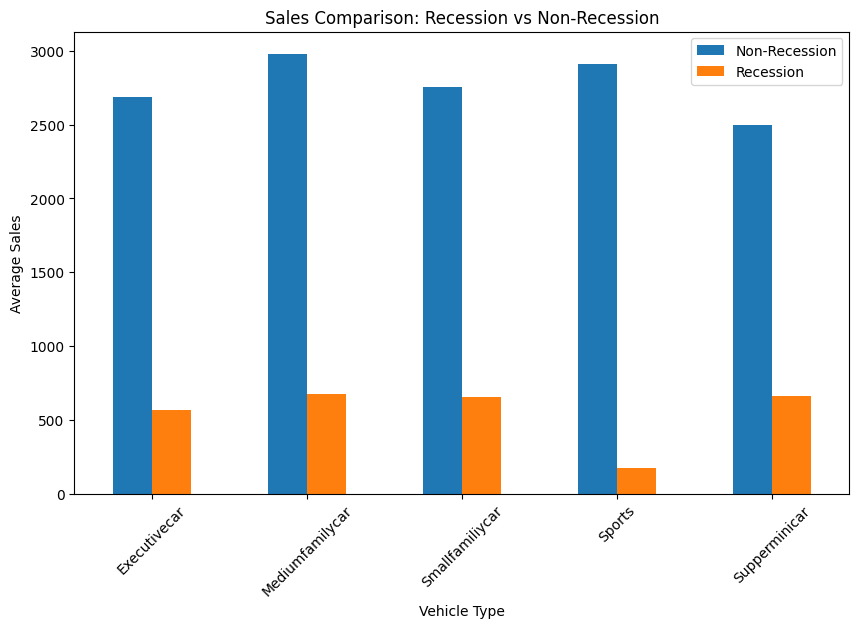

In [7]:
#Use the Matplotlib Library to create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.
grouped = df.groupby(['Vehicle_Type', 'Recession'])['Automobile_Sales'].mean().unstack()
grouped.plot(kind='bar', figsize=(10,6))
plt.title("Sales Comparison: Recession vs Non-Recession")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Sales")
plt.legend(["Non-Recession", "Recession"])
plt.xticks(rotation=45)
plt.show()

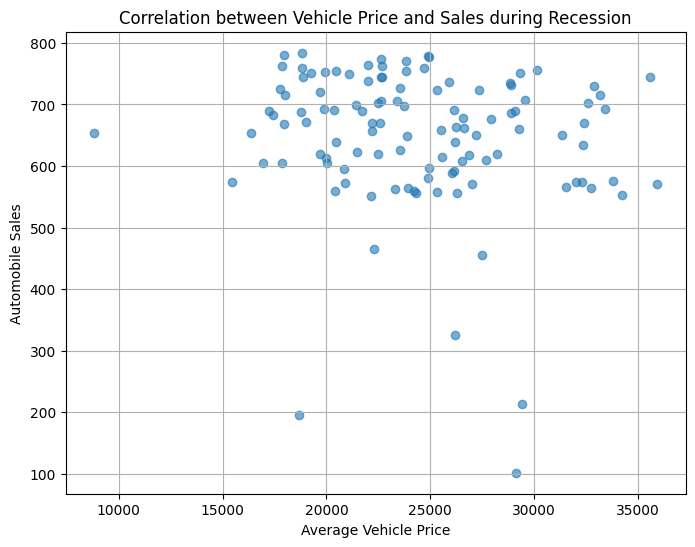

In [8]:
#Use the functionality of Matplotlib to develop a scatter plot to identify the correlation between average vehicle price relate to the sales volume during recessions.
recession_df = df[df['Recession'] == 1]
plt.figure(figsize=(8,6))
plt.scatter(recession_df['Price'], 
            recession_df['Automobile_Sales'],
            alpha=0.6)
plt.title("Correlation between Vehicle Price and Sales during Recession")
plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.grid(True)
plt.show()

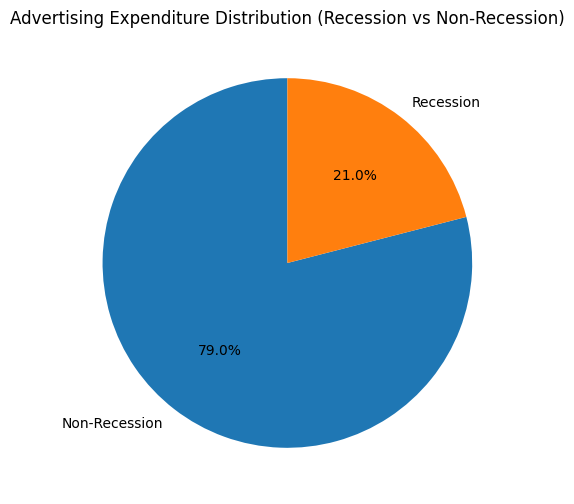

In [9]:
#Create a pie chart to display the portion of advertising expenditure of. Automotive during recession and non-recession periods.
grouped = df.groupby('Recession')['Advertising_Expenditure'].sum()
labels = ['Non-Recession', 'Recession']
plt.figure(figsize=(6,6))
plt.pie(grouped,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Advertising Expenditure Distribution (Recession vs Non-Recession)")
plt.show()

<Axes: xlabel='Automobile_Sales', ylabel='Count'>

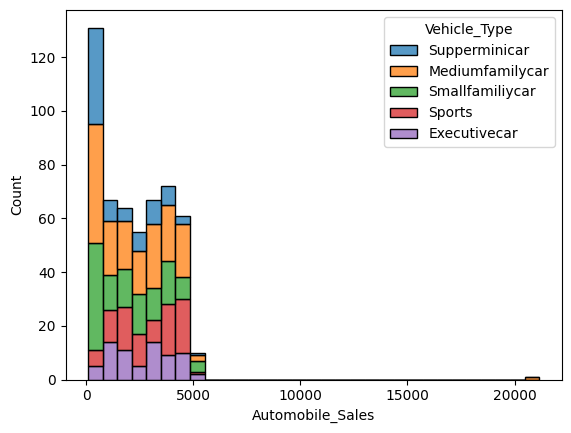

In [11]:
#Using Seaborn library create a stacked histogram which will capture Automobile Sales for Vehicle Types.
sns.histplot(data=df, x="Automobile_Sales", hue="Vehicle_Type", multiple="stack")

<Axes: xlabel='Price', ylabel='Density'>

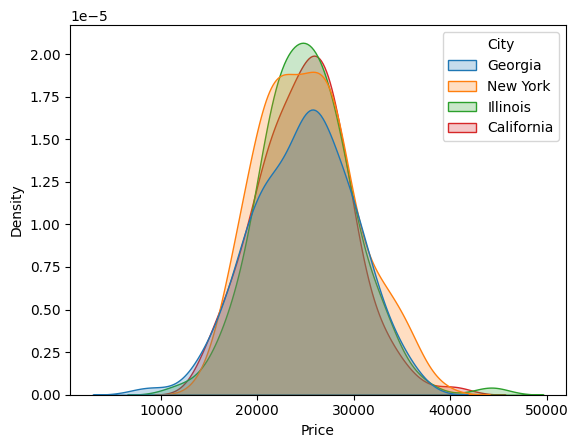

In [12]:
#Create a distribution plot (kernel density estimation plot) to understand the distribution of Price for different Cities
sns.kdeplot(data=df, x="Price", hue="City", fill=True)

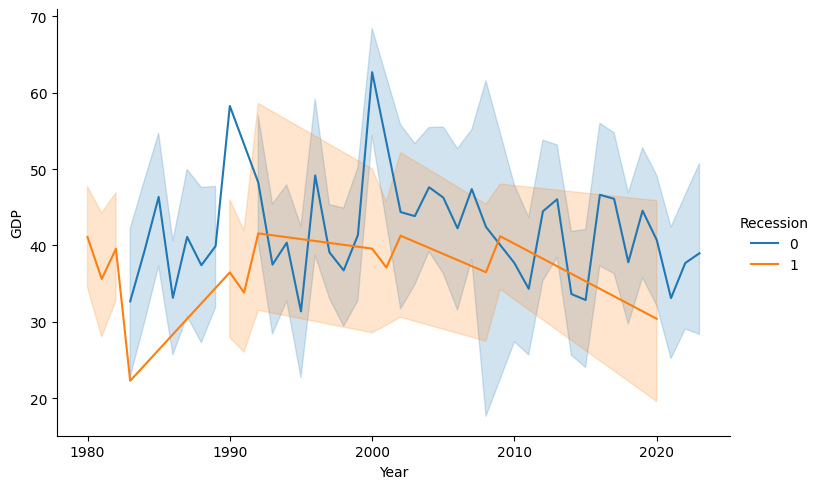

In [13]:
#Create a relation plot to visualise how along with the effect of Recession, GDP has changed with time(Year)
sns.relplot(data=df, x="Year", y="GDP", hue="Recession", kind="line", height=5, aspect=1.5)


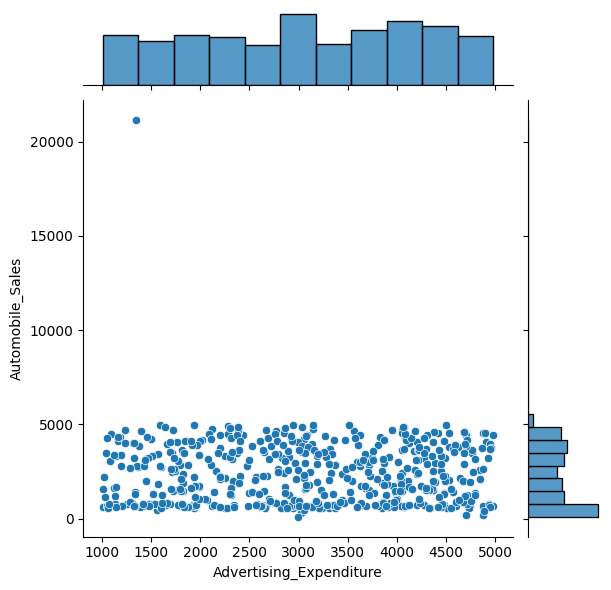

In [14]:
#Prepare a Joint Plot to understand relation between Price, Adverstising_Expenditure and Automobile_Sales.
sns.jointplot(data=df,  x="Advertising_Expenditure", y="Automobile_Sales", kind="scatter")


<Axes: >

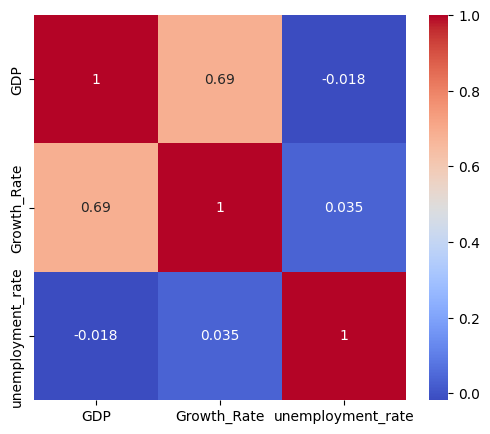

In [16]:
#Create a heat map to understand correlation for GDP, Growth_Rate and Unemployment_Rate.
import numpy as np
corr = df[["GDP", "Growth_Rate", "unemployment_rate"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 31.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 27.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 29.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(ms

<Axes: xlabel='Month', ylabel='Automobile_Sales'>

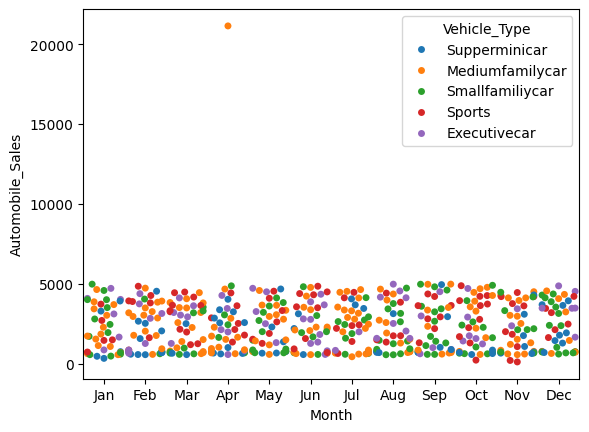

In [17]:
#Make a swarm categorical Plot to deduce the automotive sales for every Automobile Type within every calendar month.
sns.swarmplot(data=df,   x="Month", y="Automobile_Sales", hue="Vehicle_Type")

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43],
 [Text(0, 0, '1980'),
  Text(1, 0, '1981'),
  Text(2, 0, '1982'),
  Text(3, 0, '1983'),
  Text(4, 0, '1984'),
  Text(5, 0, '1985'),
  Text(6, 0, '1986'),
  Text(7, 0, '1987'),
  Text(8, 0, '1988'),
  Text(9, 0, '1989'),
  Text(10, 0, '1990'),
  Text(11, 0, '1991'),
  Text(12, 0, '1992'),
  Text(13, 0, '1993'),
  Text(14, 0, '1994'),
  Text(15, 0, '1995'),
  Text(16, 0, '1996'),
  Text(17, 0, '1997'),
  Text(18, 0, '1998'),
  Text(19, 0, '1999'),
  Text(20, 0, '2000'),
  Text(21, 0, '2001'),
  Text(22, 0, '2002'),
  Text(23, 0, '2003'),
  Text(24, 0, '2004'),
  Text(25, 0, '2005'),
  Text(26, 0, '2006'),
  Text(27, 0, '2007'),
  Text(28, 0, '2008'),
  Text(29, 0, '2009'),
  Text(30, 0, '2010'),
  Text(31, 0, '2011'),
  Text(32, 0, '2012

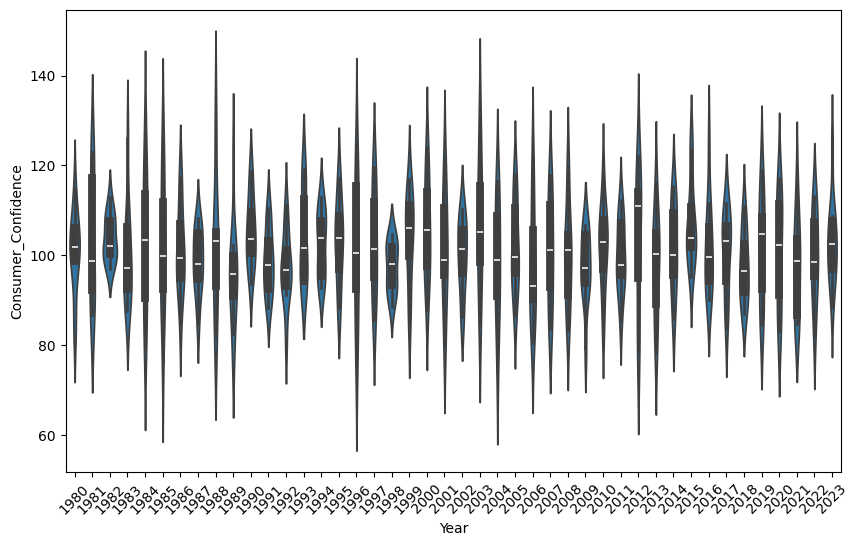

In [20]:
#Prepare a Violin Plot of how Consumer_Confidence has changed with every progressing year.
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="Year",  y="Consumer_Confidence")
plt.xticks(rotation=45)


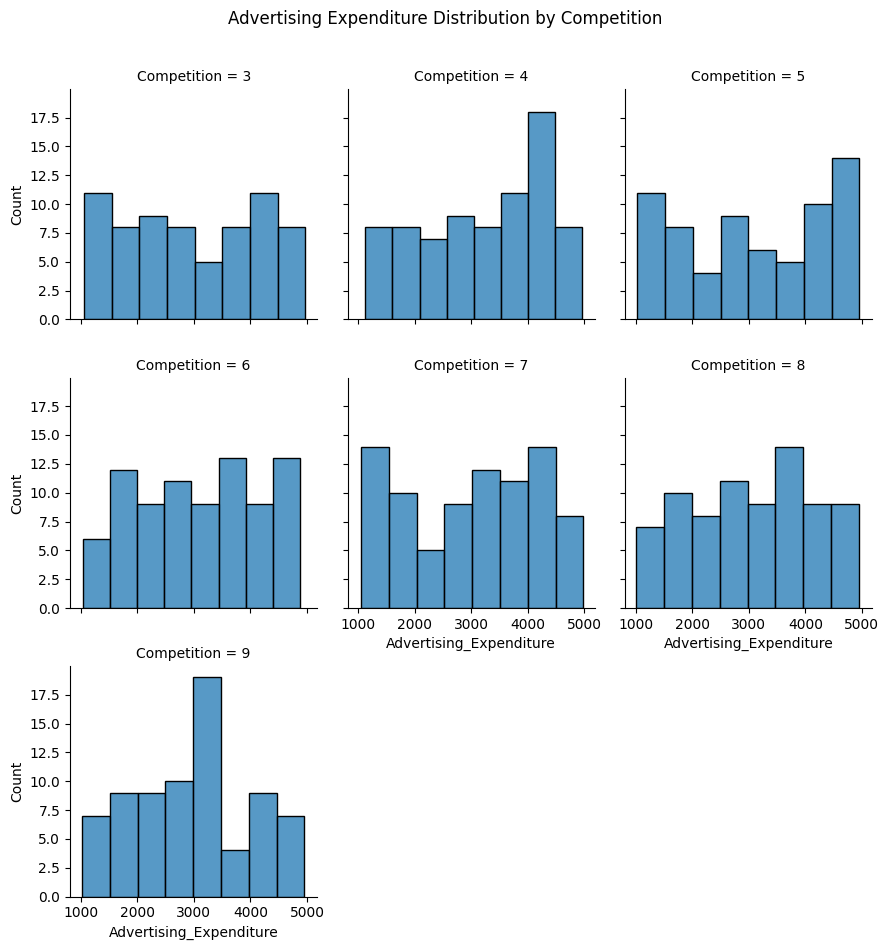

In [21]:
#Create a facet grid of Competition to view the histogram of Adverstising_Expenditure.
g = sns.FacetGrid(df, col="Competition", col_wrap=3)
g.map(sns.histplot, "Advertising_Expenditure")
g.fig.suptitle("Advertising Expenditure Distribution by Competition", y=1.05)
plt.show()